In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras import models
from tensorflow.keras.utils import image_dataset_from_directory

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random Seed :", SEED)

Random Seed : 42


In [3]:
# Dataset Path

DATASET_PATH = Path(
    r"E:\Nit RKL projects\SkinDisease-Detection-System\SkinDisease_Prepared"
)

TRAIN_DIR = DATASET_PATH / "train"
VAL_DIR = DATASET_PATH / "validation"
TEST_DIR = DATASET_PATH / "test"

print("Train      :", TRAIN_DIR)
print("Validation :", VAL_DIR)
print("Test       :", TEST_DIR)

Train      : E:\Nit RKL projects\SkinDisease-Detection-System\SkinDisease_Prepared\train
Validation : E:\Nit RKL projects\SkinDisease-Detection-System\SkinDisease_Prepared\validation
Test       : E:\Nit RKL projects\SkinDisease-Detection-System\SkinDisease_Prepared\test


In [4]:
# Verify Dataset
print("=" * 60)

for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:

    print(f"\n{split.name.upper()}")

    total = 0

    for cls in sorted(os.listdir(split)):

        class_path = split / cls

        if class_path.is_dir():

            count = len(list(class_path.glob("*.*")))

            total += count

            print(f"{cls:<20} : {count}")

    print(f"Total Images : {total}")

print("=" * 60)


TRAIN
Benign_Tumors        : 930
Skin_Cancer          : 597
Unknown_Normal       : 1404
Vascular_Tumors      : 462
Total Images : 3393

VALIDATION
Benign_Tumors        : 163
Skin_Cancer          : 96
Unknown_Normal       : 247
Vascular_Tumors      : 81
Total Images : 587

TEST
Benign_Tumors        : 121
Skin_Cancer          : 77
Unknown_Normal       : 189
Vascular_Tumors      : 60
Total Images : 447


In [5]:
# Load Dataset
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

NUM_CLASSES = len(class_names)

print("\nClass Names")

for i, cls in enumerate(class_names):

    print(f"{i} : {cls}")

print("\nNumber of Classes :", NUM_CLASSES)

Found 3393 files belonging to 4 classes.
Found 587 files belonging to 4 classes.
Found 447 files belonging to 4 classes.

Class Names
0 : Benign_Tumors
1 : Skin_Cancer
2 : Unknown_Normal
3 : Vascular_Tumors

Number of Classes : 4


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(
    lambda x, y: (preprocess(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (preprocess(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (preprocess(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Dataset pipeline ready.")

Dataset pipeline ready.


In [7]:
# Build MobileNetV2 Model

base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build Model
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.30)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="SkinDisease_MobileNetV2"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
model.summary()

Model: "SkinDisease_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,427,588 (9.26 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [9]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy"
    ]

)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [10]:
early_stop = callbacks.EarlyStopping(

    monitor="val_accuracy",

    mode="max",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    min_lr=1e-6,

    verbose=1

)

checkpoint = callbacks.ModelCheckpoint(

    "best_mobilenetv2.keras",

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    verbose=1

)

print("Callbacks Ready!")

Callbacks Ready!


In [11]:
EPOCHS = 20

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.5379 - loss: 1.3369
Epoch 1: val_accuracy improved from None to 0.63543, saving model to best_mobilenetv2.keras

Epoch 1: finished saving model to best_mobilenetv2.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 66s 487ms/step - accuracy: 0.5379 - loss: 1.3369 - val_accuracy: 0.6354 - val_loss: 0.8521 - learning_rate: 1.0000e-04
Epoch 2/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6627 - loss: 0.8927
Epoch 2: val_accuracy improved from 0.63543 to 0.69676, saving model to best_mobilenetv2.keras

Epoch 2: finished saving model to best_mobilenetv2.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 65s 609ms/step - accuracy: 0.6625 - loss: 0.8928 - val_accuracy: 0.6968 - val_loss: 0.7690 - learning_rate: 1.0000e-04
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6953 - loss: 0.7898
Epoch 3: val_accuracy improved from 0.69676 to 0.70017, saving model to best_mobilenetv2.keras

Epoch 3: finished saving model to best_mo

In [12]:
# Evaluate Model

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("="*60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print("="*60)

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 357ms/step - accuracy: 0.8233 - loss: 0.4953
Test Loss     : 0.4953
Test Accuracy : 0.8233


In [13]:
predictions = model.predict(test_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = np.concatenate([
    y.numpy()
    for _, y in test_ds
])

14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 614ms/step


In [14]:
report = classification_report(

    y_true,

    y_pred,

    target_names=class_names,

    digits=4,

    output_dict=True

)

print(classification_report(

    y_true,

    y_pred,

    target_names=class_names,

    digits=4

))

                 precision    recall  f1-score   support

  Benign_Tumors     0.7007    0.8512    0.7687       121
    Skin_Cancer     0.7097    0.5714    0.6331        77
 Unknown_Normal     0.9844    1.0000    0.9921       189
Vascular_Tumors     0.6957    0.5333    0.6038        60

       accuracy                         0.8233       447
      macro avg     0.7726    0.7390    0.7494       447
   weighted avg     0.8215    0.8233    0.8177       447



<Figure size 800x800 with 0 Axes>

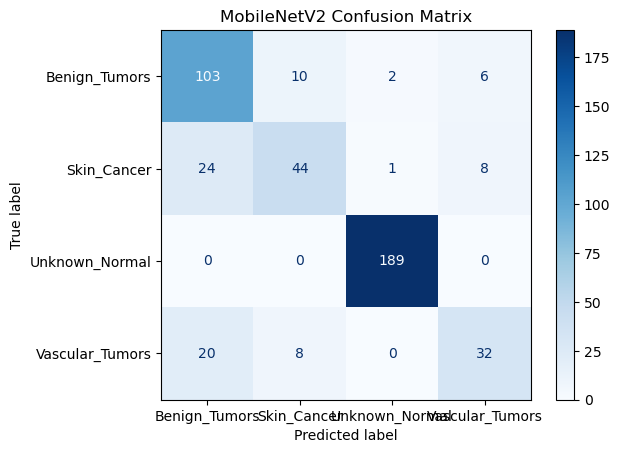

In [15]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)

plt.figure(figsize=(8,8))

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("MobileNetV2 Confusion Matrix")

plt.show()

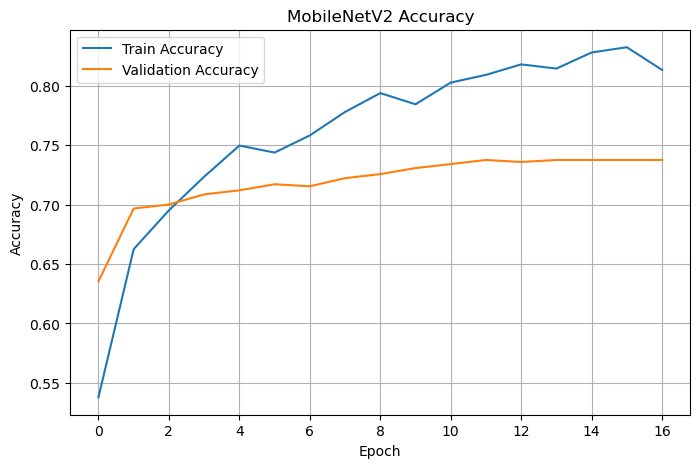

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("MobileNetV2 Accuracy")

plt.legend()

plt.grid(True)

plt.show()

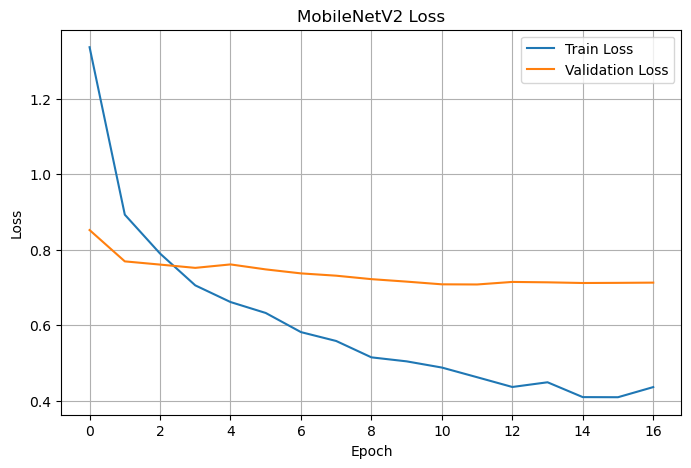

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("MobileNetV2 Loss")

plt.legend()

plt.grid(True)

plt.show()

In [18]:
results = pd.DataFrame({

    "Model":["MobileNetV2"],

    "Dataset":["Skin Disease (4 Classes)"],

    "Train Images":[3393],

    "Validation Images":[587],

    "Test Images":[447],

    "Image Size":["224x224"],

    "Epochs":[len(history.history["accuracy"])],

    "Batch Size":[32],

    "Optimizer":["Adam"],

    "Learning Rate":[1e-4],

    "Transfer Learning":["Yes"],

    "Fine Tuning":["No"],

    "Train Accuracy":[
        max(history.history["accuracy"]) * 100
    ],

    "Validation Accuracy":[
        max(history.history["val_accuracy"]) * 100
    ],

    "Test Accuracy":[
        test_accuracy * 100
    ],

    "Test Loss":[
        test_loss
    ],

    "Precision":[
        report["weighted avg"]["precision"] * 100
    ],

    "Recall":[
        report["weighted avg"]["recall"] * 100
    ],

    "Weighted F1 Score":[
        report["weighted avg"]["f1-score"] * 100
    ],

    "Macro F1 Score":[
        report["macro avg"]["f1-score"] * 100
    ],

    "Notes":[
        "Baseline MobileNetV2"
    ]

})

results.to_csv(
    "MobileNetV2_Results.csv",
    index=False
)

print(results)
print("\nResults saved to MobileNetV2_Results.csv")

         Model                   Dataset  Train Images  Validation Images  \
0  MobileNetV2  Skin Disease (4 Classes)          3393                587   

   Test Images Image Size  Epochs  Batch Size Optimizer  Learning Rate  ...  \
0          447    224x224      17          32      Adam         0.0001  ...   

  Fine Tuning Train Accuracy  Validation Accuracy  Test Accuracy  Test Loss  \
0          No      83.259654            73.764908      82.326621   0.495316   

   Precision     Recall  Weighted F1 Score  Macro F1 Score  \
0  82.150667  82.326622          81.765971       74.941245   

                  Notes  
0  Baseline MobileNetV2  

[1 rows x 21 columns]

Results saved to MobileNetV2_Results.csv
